In [8]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [9]:
L = 1.0  # Длина балки (м)
E = 200e9  # Модуль Юнга (Па)
rho = 7800  # Плотность материала (кг/м³)
w = 0.01  # Ширина сечения (м)
h = 0.01  # Высота сечения (м)
Iy = w * h ** 3 / 12  # Момент инерции (м⁴)
mu = rho * w * h  # Масса на единицу длины (кг/м)

In [10]:
# Параметры нагрузки и моделирования
freq = 440  # Частота нагрузки (Гц)
amp = 20  # Амплитуда нагрузки (Н/м)
t_max = 10.0  # Время моделирования (с)
N = 40  # Количество точек дискретизации
damping = 0.1  # Коэффициент демпфирования


In [11]:
x = np.linspace(0, L, N)
dx = x[1] - x[0]

In [12]:
def build_d4_matrix(N, dx):
    """Построение матрицы четвертой производной с граничными условиями"""
    mat = np.zeros((N, N))
    for i in range(2, N - 2):
        mat[i, i - 2] = 1
        mat[i, i - 1] = -4
        mat[i, i] = 6
        mat[i, i + 1] = -4
        mat[i, i + 2] = 1

    # Граничные условия для консольной балки:
    # Закрепленный конец (x=0): y=0, y'=0
    mat[0, 0] = 1
    mat[1, 0] = -1
    mat[1, 1] = 1

    # Свободный конец (x=L): y''=0, y'''=0
    mat[-1, -3] = 1
    mat[-1, -2] = -2
    mat[-1, -1] = 1

    mat[-2, -4] = 1
    mat[-2, -3] = -3
    mat[-2, -2] = 3
    mat[-2, -1] = -1

    return mat / dx ** 4


D4 = build_d4_matrix(N, dx)

In [18]:
def q(t):
    return amp * np.sin(2 * np.pi * freq * t) * np.ones(N)


def beam_ode(t, Y):
    y = Y[:N]
    v = Y[N:]

    dydt = v
    dvdt = (q(t) - E * Iy * D4 @ y - v) / mu

    # Граничные условия для закрепленного конца
    dydt[0] = 0  # y(0) = 0
    if N > 1:
        dydt[1] = 0  # y'(0) = 0

    return np.concatenate([dydt, dvdt])

In [19]:
y0 = np.zeros(N)
v0 = np.zeros(N)

# Решение системы ОДУ
sol = solve_ivp(beam_ode, [0, t_max], np.concatenate([y0, v0]),
                t_eval=np.linspace(0, t_max, 200),
                method='Radau', rtol=1e-4, atol=1e-6)

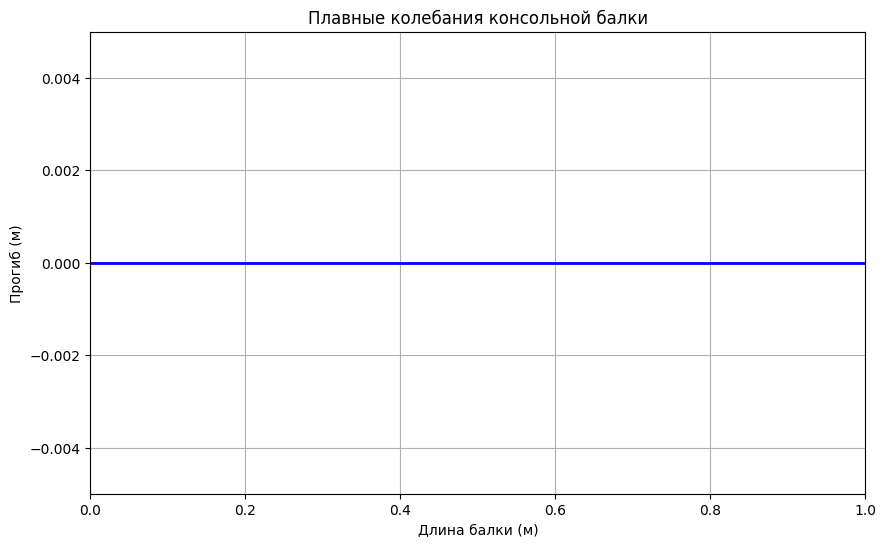

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
line, = ax.plot(x, sol.y[:N, 0], 'b-', linewidth=2)
ax.set_xlim(0, L)
ax.set_ylim(-0.005, 0.005)
ax.set_xlabel('Длина балки (м)')
ax.set_ylabel('Прогиб (м)')
ax.set_title('Плавные колебания консольной балки')
ax.grid(True)


def update(frame):
    """Обновление анимации"""
    line.set_ydata(sol.y[:N, frame])
    return line,


# Создание анимации
ani = FuncAnimation(fig, update, frames=len(sol.t), blit=True, interval=50)
plt.show()

In [23]:
from IPython.display import HTML

HTML(ani.to_jshtml())